# 髮型分類器 Hair Type Classifier
本作業使用 ResNet50V2 預訓練模型 進行 遷移學習（transfer learning），將原本用於 ImageNet 大型影像分類的模型，改用於三種類型頭髮影像分類：直髮、波浪髮、捲髮

In [ ]:
!pip install -q gdown
!gdown "https://drive.google.com/uc?export=download&id=1qPmJ4PWSYHaQ-0Xw5be6Uk4YGBfw8g8n" -O data.zip --fuzzy
!file data.zip

Downloading...
From (original): https://drive.google.com/uc?id=1qPmJ4PWSYHaQ-0Xw5be6Uk4YGBfw8g8n
From (redirected): https://drive.google.com/uc?id=1qPmJ4PWSYHaQ-0Xw5be6Uk4YGBfw8g8n&confirm=t&uuid=b97d0169-a862-4025-a7bf-e121415af9ee
To: /content/data.zip
100% 61.0M/61.0M [00:00<00:00, 67.8MB/s]
data.zip: Zip archive data, at least v2.0 to extract, compression method=deflate


In [ ]:
# 解壓縮到 data 資料夾
!unzip -q data.zip -d data

# 看裡面有什麼
!ls -R data

data:
README.dataset.txt  README.roboflow.txt  test  train  valid

data/test:
1_straight  2_wavy  3_curly

data/test/1_straight:
1a-12_png.rf.c350b97f4a6cf3159aa5a9d887418e18.jpg
1a-31_png.rf.c61b19c0913f8b45d8550df97a40899d.jpg
1a-46_png.rf.81e3b707a8e030647fb29cb533186333.jpg
1b-14_png.rf.42964a13e1fe75cb167996f26e8142b8.jpg
1b-15_png.rf.6dfc14bd617aa81edffb7ec6db82bcee.jpg
1b-24_png.rf.01b9907271ba3da66976c6c528eb11fb.jpg
1c-26_png.rf.c9b8029ca3abab49aac19a1d76aee4f1.jpg
1c-2_png.rf.e818ba53a588b801d2bd05f57cab7f52.jpg
1c-35_png.rf.8a57d7482c0e88e84ec9a663ed439c81.jpg
1c-44_png.rf.73639f681d5d6bfc7e2944878e83878f.jpg
1c-45_png.rf.4b9c12f0d3c4d63d47a47b9d0a2bc186.jpg
1c-56_png.rf.105e27015668d9b051e3e4cf0e4e0086.jpg

data/test/2_wavy:
2a-13_png.rf.1e473c4dd70b429cadb97857bbb8543b.jpg
2a-1_png.rf.4e95be43e404cc24c8a5a6b6d525abf2.jpg
2a-23_png.rf.b063818f074e515d0209f7136dc57462.jpg
2a-31_png.rf.1893209df25e0226d3ebf54add0ef8a9.jpg
2a-33_png.rf.ab5fa2980b5136795d9dfb26c0229667.jpg
2b-1

In [ ]:
import os

for root, dirs, files in os.walk("data"):
    level = root.replace("data", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files[:10]:   # 每層先只顯示前10個檔案，避免太長
        print(f"{subindent}{f}")

data/
  README.dataset.txt
  README.roboflow.txt
  train/
    1_straight/
      1a-45_png.rf.e2aeaf96c0fb940b02141b12089204a7.jpg
      1a-19_png.rf.380ffc6f3df896f96efe0b7f67765644.jpg
      1b-42_png.rf.70270bed83ad3ebcbe4d3949bbe94856.jpg
      1a-43_png.rf.860d78cf449bb5adf4127e99e2a66ace.jpg
      1c-14_png.rf.a2b7c19546795b764ae4fe12c9bb5eb7.jpg
      1a-63_png.rf.c2855c0326966c8867c4e9bfe965efad.jpg
      1a-62_png.rf.98040886a407d3afa61d73999212ca8b.jpg
      1a-52_png.rf.c9aa5ba3353a2d6dd9a44b8a25bef1d3.jpg
      1c-34_png.rf.2337b2a4ac4b49abda2b3835e868d1d7.jpg
      1c-61_png.rf.06739227d049804c3812050edb1ef116.jpg
    2_wavy/
      2c-47_png.rf.feabfd90b2003f582653859cc120f7dc.jpg
      2a-41_png.rf.ec9b788c7aeb3812717e9b2c0f21c8ba.jpg
      2b-46_png.rf.c2b637523701659878b7ecdb9bc68f9f.jpg
      2a-6_png.rf.5d4c80ff5c492a40221ca036be5f26c8.jpg
      2a-6_png.rf.b230872b75985795937d55717f9b6654.jpg
      2c-36_png.rf.3cbc91b456ee39849617c192abdc62cd.jpg
      2a-19_png.rf.8

分類是：

- 1_straight
- 2_wavy
- 3_curly

中文顯示用：

- 直髮
- 波浪髮
- 捲髮

# 1.確認資料已經在 /content/data

In [ ]:
!ls /content/data
!ls /content/data/train

README.dataset.txt  README.roboflow.txt  test  train  valid
1_straight  2_wavy  3_curly


# 2. 安裝套件 和名稱設定

In [ ]:
!pip install -q gradio

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import gradio as gr

from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image

In [ ]:
# 辨識類別英文名稱
category_en = "straight,wavy,curly"

# 顯示用中文名稱
category_zh = "直髮,波浪髮,捲髮"

# App 名稱
title = "Hair Type Classifier"

# App 說明
description = "請上傳一張頭髮照片，我會判斷它是直髮、波浪髮，還是捲髮。"

categories = category_en.split(",")
labels_zh = category_zh.split(",")
N = len(categories)

print("英文類別：", categories)
print("中文類別：", labels_zh)
print("類別數量：", N)

英文類別： ['straight', 'wavy', 'curly']
中文類別： ['直髮', '波浪髮', '捲髮']
類別數量： 3


# 3. 修改資料路徑

In [ ]:
train_dir = "/content/data/train"
valid_dir = "/content/data/valid"
test_dir  = "/content/data/test"

img_size = (224, 224)
batch_size = 32

In [ ]:
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

valid_ds = image_dataset_from_directory(
    valid_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
print("資料夾類別名稱：", class_names)

Found 1122 files belonging to 3 classes.
Found 107 files belonging to 3 classes.
Found 54 files belonging to 3 classes.
資料夾類別名稱： ['1_straight', '2_wavy', '3_curly']


跑一張圖看看

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

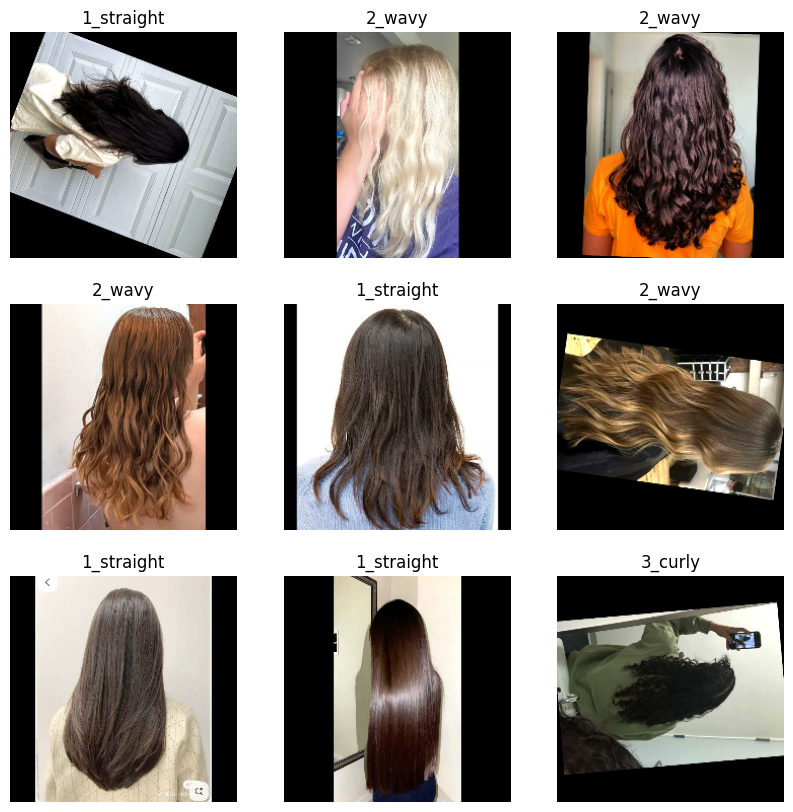

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# 4. **建立 ResNet50V2 遷移學習模型**

In [ ]:
base_model = ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# 先凍結預訓練模型權重
base_model.trainable = False

model = Sequential([
    tf.keras.layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(N, activation="softmax")
])

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,570,947 (89.92 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 426ms/step - accuracy: 0.5873 - loss: 0.9072 - val_accuracy: 0.7944 - val_loss: 0.4967
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7861 - loss: 0.5048 - val_accuracy: 0.7757 - val_loss: 0.4224
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.8405 - loss: 0.3919 - val_accuracy: 0.8037 - val_loss: 0.3993
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.8717 - loss: 0.3129 - val_accuracy: 0.8318 - val_loss: 0.3691
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8939 - loss: 0.2789 - val_accuracy: 0.7850 - val_loss: 0.3794
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8984 - loss: 0.2651 - val_accuracy: 0.8131 - val_loss: 0.3543
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9242 - loss: 0.2219 - val_accuracy: 0.8037 - val_loss: 0.3617
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.9278 - loss: 0.2028 - val_accuracy: 0.8224 

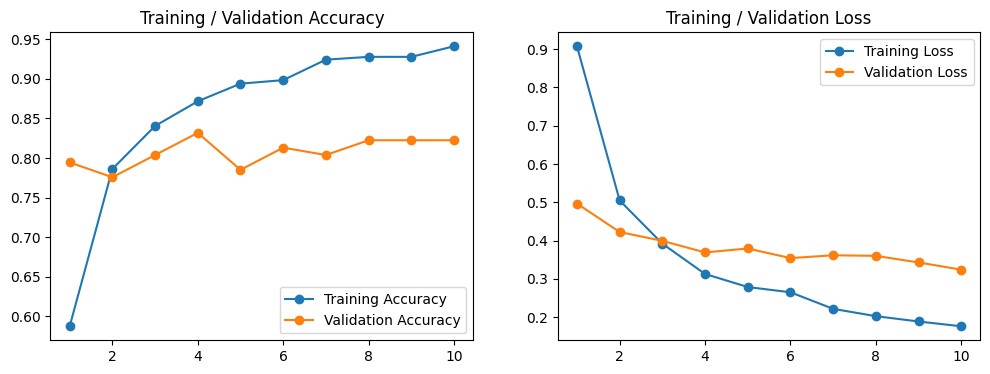

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="o", label="Validation Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.title("Training / Validation Loss")
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step - accuracy: 0.8519 - loss: 0.3374
Test Loss: 0.3374
Test Accuracy: 0.8519


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


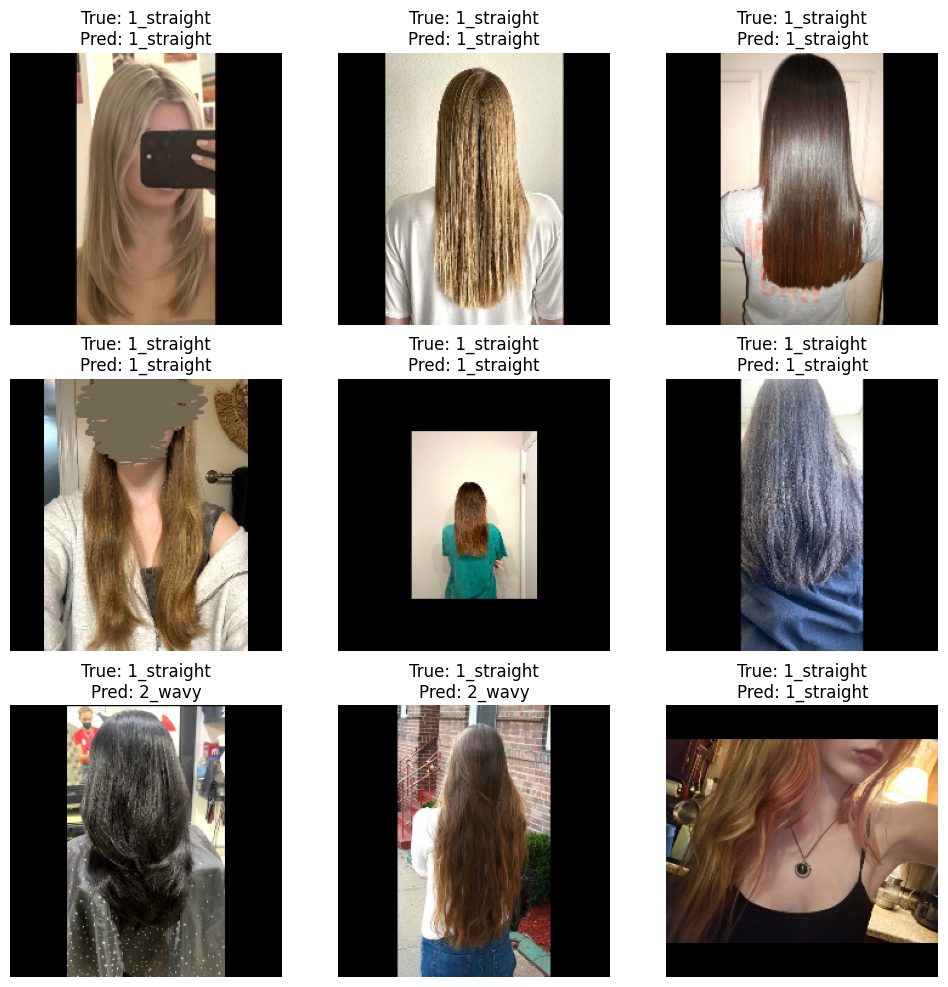

In [ ]:
import numpy as np

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_labels[i]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")
    plt.show()

# 5. Gradio App

In [ ]:
display_map = {
    "1_straight": "straight / 直髮",
    "2_wavy": "wavy / 波浪髮",
    "3_curly": "curly / 捲髮"
}

def predict_hair(img):
    img = img.resize((224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    pred = model.predict(x, verbose=0)[0]

    result = {}
    for i, score in enumerate(pred):
        class_name = class_names[i]
        show_name = display_map[class_name]
        result[show_name] = float(score)

    return result

In [ ]:
demo = gr.Interface(
    fn=predict_hair,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title=title,
    description=description
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8b91f4417e97a69c9f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
